In [1]:
# ============================================================
# PHASE 18 — NEGATIVE-SET SENSITIVITY ANALYSIS
# ============================================================
# Goal:
# Test whether model conclusions are robust to the choice of negative genes.
#
# Why:
# In disease-gene prediction, negative genes are often "unknown positives"
# rather than true non-disease genes. Reviewers may question whether the
# model learns T2D biology or merely biases in the sampled negatives.
#
# This phase evaluates model robustness under multiple negative-set scenarios:
# 1. Original balanced negatives
# 2. Random negative subsets
# 3. Hard negatives: negatives closest to positives in embedding space
# 4. Easy negatives: negatives farthest from positives
# 5. Optional length/GC matched negatives if metadata is available
#
# Outputs:
# - scenario-level repeated CV metrics
# - robustness summary
# - performance degradation table
# - figures for PR-AUC/MCC across negative scenarios
# - manuscript-ready wording
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
SHARED_DIR = PHASE3_DIR / "shared_dataset"

PHASE18_DIR = PROJECT_DIR / "model" / "phase18_negative_set_sensitivity_analysis"
RESULT_DIR = PHASE18_DIR / "results"
FIGURE_DIR = PHASE18_DIR / "figures"
EXCEL_DIR = PHASE18_DIR / "excel"
REPORT_DIR = PHASE18_DIR / "reports"

for d in [PHASE18_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 18 output:", PHASE18_DIR)

Mounted at /content/drive
Phase 18 output: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_npy_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    arr = np.load(path, allow_pickle=True)
    print("Loaded:", path, arr.shape)
    return arr


def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def choose_threshold_by_mcc(y_true, y_score, n_grid=501):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    thresholds = np.unique(np.quantile(y_score, np.linspace(0, 1, n_grid)))

    best_thr = float(thresholds[0])
    best_mcc = -999

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(thr)

    return best_thr, float(best_mcc)


def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def evaluate_prediction(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }


def build_model(model_type, seed=42):
    if model_type == "svm_rbf":
        return Pipeline([
            ("variance", VarianceThreshold()),
            ("scaler", StandardScaler()),
            ("model", SVC(
                C=1.0,
                gamma="scale",
                kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=seed
            ))
        ])

    if model_type == "random_forest":
        return Pipeline([
            ("variance", VarianceThreshold()),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=seed,
                n_jobs=-1
            ))
        ])

    raise ValueError(f"Unknown model_type: {model_type}")


def bootstrap_ci_mean(values, n_boot=3000, seed=42, ci=95):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)

    boot_means = []
    for _ in range(n_boot):
        boot_means.append(np.mean(rng.choice(values, size=len(values), replace=True)))

    alpha = (100 - ci) / 2
    return (
        float(np.percentile(boot_means, alpha)),
        float(np.percentile(boot_means, 100 - alpha))
    )


def find_gene_column(df):
    candidates = ["gene_symbol", "gene", "Gene", "symbol", "gene_name", "hgnc_symbol"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_label_column(df):
    candidates = ["label", "y", "target", "class", "is_positive", "t2d_label"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

In [4]:
# ============================================================
# LOAD SHARED FEATURE ARRAYS
# ============================================================

# Protein
SHARED_DIR = PHASE3_DIR / "features"
PHASE5_DIR1 = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
SHARED_DIR1 = PHASE5_DIR1 / "embeddings"
SHARED_DIR2 = PHASE3_DIR / "shared_dataset"

# Protein
X_train_protein = load_npy_required(SHARED_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein   = load_npy_required(SHARED_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein  = load_npy_required(SHARED_DIR / "X_test_protein_protbert_sw_v1.npy")

# Handcrafted multimodal: ProtBERT + K3/K4/Basic
X_train_hand = load_npy_required(SHARED_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_hand   = load_npy_required(SHARED_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_hand  = load_npy_required(SHARED_DIR / "X_test_combined_protein_genomic_v1.npy")

# DNABERT-2 multimodal: ProtBERT + DNABERT-2
X_train_dna = load_npy_required(SHARED_DIR1 / "X_train_combined_protbert_sw_dnabert2_v1.npy")
X_val_dna   = load_npy_required(SHARED_DIR1 / "X_val_combined_protbert_sw_dnabert2_v1.npy")
X_test_dna  = load_npy_required(SHARED_DIR1 / "X_test_combined_protbert_sw_dnabert2_v1.npy")

# Labels
y_train = load_npy_required(SHARED_DIR2 / "y_train_multimodal_v1.npy").astype(int)
y_val   = load_npy_required(SHARED_DIR2 / "y_val_multimodal_v1.npy").astype(int)
y_test  = load_npy_required(SHARED_DIR2 / "y_test_multimodal_v1.npy").astype(int)

# Combine
X_protein_full = np.vstack([X_train_protein, X_val_protein, X_test_protein])
X_hand_full = np.vstack([X_train_hand, X_val_hand, X_test_hand])
X_dna_full = np.vstack([X_train_dna, X_val_dna, X_test_dna])
y_full = np.concatenate([y_train, y_val, y_test]).astype(int)

PROTEIN_DIM = 1024
X_genomic_full = X_hand_full[:, PROTEIN_DIM:]

print("Full dataset:")
print("Protein:", X_protein_full.shape)
print("Genomic:", X_genomic_full.shape)
print("Handcrafted multimodal:", X_hand_full.shape)
print("DNABERT-2 multimodal:", X_dna_full.shape)
print("Labels:", y_full.shape, np.bincount(y_full))

Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy (1264, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy (1264, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_combined_protbert_sw_dnabert2_v1.npy (1264, 1792

In [5]:
# ============================================================
# LOAD SAMPLE METADATA IF AVAILABLE
# ============================================================
# The code tries to find metadata files with 1,806 rows.
# If not found, it creates generic sample IDs.
# ============================================================

metadata_candidates = []

patterns = [
    "*metadata*.csv",
    "*sample*.csv",
    "*split*.csv",
    "*dataset*.csv",
    "*gene*.csv",
    "*multimodal*.csv"
]

for pattern in patterns:
    for path in PROJECT_DIR.rglob(pattern):
        try:
            if path.stat().st_size > 100 * 1024 * 1024:
                continue

            df = pd.read_csv(path)
            if len(df) in [len(y_full), len(y_train), len(y_val), len(y_test)]:
                metadata_candidates.append({
                    "path": str(path),
                    "shape": df.shape,
                    "columns": "; ".join(df.columns.astype(str).tolist()[:30])
                })
        except Exception:
            pass

metadata_candidates_df = pd.DataFrame(metadata_candidates)
display(metadata_candidates_df.head(30))

save_df(metadata_candidates_df, RESULT_DIR / "phase18_metadata_candidates.csv")

sample_metadata_df = None

for _, row in metadata_candidates_df.iterrows():
    path = Path(row["path"])
    try:
        df = pd.read_csv(path)
        if len(df) == len(y_full):
            sample_metadata_df = df.copy()
            print("Using metadata:", path)
            break
    except Exception:
        pass

if sample_metadata_df is None:
    print("No full metadata found. Creating generic metadata.")
    sample_metadata_df = pd.DataFrame({
        "sample_index": np.arange(len(y_full)),
        "gene_symbol": [f"SAMPLE_{i}" for i in range(len(y_full))],
        "label": y_full
    })
else:
    sample_metadata_df = sample_metadata_df.reset_index(drop=True)
    sample_metadata_df["sample_index"] = np.arange(len(sample_metadata_df))

    label_col = find_label_column(sample_metadata_df)
    if label_col is None:
        sample_metadata_df["label"] = y_full
    else:
        sample_metadata_df["label"] = sample_metadata_df[label_col].astype(int)

    gene_col = find_gene_column(sample_metadata_df)
    if gene_col is None:
        sample_metadata_df["gene_symbol"] = [f"SAMPLE_{i}" for i in range(len(sample_metadata_df))]
    else:
        sample_metadata_df["gene_symbol"] = sample_metadata_df[gene_col].astype(str)

# Ensure label matches loaded arrays
sample_metadata_df["label_from_array"] = y_full
sample_metadata_df["label_match"] = sample_metadata_df["label"].astype(int) == sample_metadata_df["label_from_array"].astype(int)

display(sample_metadata_df.head())
display(sample_metadata_df["label_match"].value_counts())

save_df(sample_metadata_df, RESULT_DIR / "phase18_sample_metadata_used.csv")

,path,shape,columns
0,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/train_genomic_metadata_v1.csv,"(1264, 3)",gene_id; gene_symbol; label
1,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/val_genomic_metadata_v1.csv,"(271, 3)",gene_id; gene_symbol; label
2,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/test_genomic_metadata_v1.csv,"(271, 3)",gene_id; gene_symbol; label
3,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/train_multimodal_metadata_v1.csv,"(1264, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
4,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/val_multimodal_metadata_v1.csv,"(271, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
5,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/test_multimodal_metadata_v1.csv,"(271, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
6,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/all_shared_multimodal_metadata_v1.csv,"(1806, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
7,/content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_dnabert2_sw2048_stride1024_partial_metadata.csv,"(1264, 7)",split; row_idx; gene_id; gene_symbol; label; sequence_length; n_windows
8,/content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_dnabert2_sw2048_stride1024_embedding_metadata.csv,"(1264, 7)",split; row_idx; gene_id; gene_symbol; label; sequence_length; n_windows
9,/content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_val_dnabert2_sw2048_stride1024_partial_metadata.csv,"(271, 7)",split; row_idx; gene_id; gene_symbol; label; sequence_length; n_windows


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_metadata_candidates.csv
Using metadata: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/all_shared_multimodal_metadata_v1.csv


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,sample_index,label_from_array
0,ENSG00000205155,PSENEN,0,0,train,PSENEN,0,1589,test,True,0,PSENEN,0,0
1,ENSG00000164530,PI16,1,1,train,PI16,1,250,train,True,1,PI16,1,1
2,ENSG00000143167,GPA33,0,2,train,GPA33,0,1634,test,True,0,GPA33,2,0
3,ENSG00000137691,CFAP300,0,3,train,CFAP300,0,511,train,True,0,CFAP300,3,0
4,ENSG00000095981,KCNK16,1,4,train,KCNK16,1,837,train,True,1,KCNK16,4,1


,count
label_match,
True,942
False,864


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_sample_metadata_used.csv


In [6]:
# ============================================================
# DEFINE NEGATIVE HARDNESS SCORES
# ============================================================
# Hard negatives are negatives close to the positive centroid.
# Easy negatives are negatives far from the positive centroid.
#
# This is not a perfect biological negative strategy, but it is useful
# as a stress test:
# - If performance collapses on hard negatives, the model may rely on easy separation.
# - If conclusions remain consistent, robustness is stronger.
# ============================================================

positive_idx = np.where(y_full == 1)[0]
negative_idx = np.where(y_full == 0)[0]

print("n positives:", len(positive_idx))
print("n negatives:", len(negative_idx))

# Use protein embeddings for hardness because protein signal dominates.
# Standardize globally only for distance calculation, not model training.
scaler_for_hardness = StandardScaler()
X_hardness = scaler_for_hardness.fit_transform(X_protein_full)

positive_centroid = X_hardness[positive_idx].mean(axis=0)

dist_to_positive_centroid = np.linalg.norm(
    X_hardness - positive_centroid,
    axis=1
)

hardness_df = pd.DataFrame({
    "sample_index": np.arange(len(y_full)),
    "label": y_full,
    "distance_to_positive_centroid": dist_to_positive_centroid
})

hardness_df = hardness_df.merge(
    sample_metadata_df[["sample_index", "gene_symbol"]],
    on="sample_index",
    how="left"
)

neg_hardness_df = hardness_df[hardness_df["label"] == 0].copy()
neg_hardness_df = neg_hardness_df.sort_values("distance_to_positive_centroid", ascending=True).reset_index(drop=True)
neg_hardness_df["hardness_rank"] = np.arange(1, len(neg_hardness_df) + 1)
neg_hardness_df["negative_type"] = pd.cut(
    neg_hardness_df["hardness_rank"],
    bins=[0, len(neg_hardness_df)*0.33, len(neg_hardness_df)*0.66, len(neg_hardness_df)],
    labels=["Hard", "Medium", "Easy"]
)

display(neg_hardness_df.head(20))
display(neg_hardness_df.tail(20))
display(neg_hardness_df["negative_type"].value_counts())

save_df(hardness_df, RESULT_DIR / "phase18_all_sample_hardness_scores.csv")
save_df(neg_hardness_df, RESULT_DIR / "phase18_negative_hardness_scores.csv")

n positives: 903
n negatives: 903


,sample_index,label,distance_to_positive_centroid,gene_symbol,hardness_rank,negative_type
0,1573,0,17.718964,IGFLR1,1,Hard
1,1745,0,18.173046,ANKRD17,2,Hard
2,665,0,19.343904,AVEN,3,Hard
3,975,0,19.390909,CDHR1,4,Hard
4,56,0,19.513464,FOXRED2,5,Hard
5,638,0,19.560436,PAGE3,6,Hard
6,1530,0,19.695122,QRICH2,7,Hard
7,324,0,19.992167,TSPAN8,8,Hard
8,517,0,20.124929,SLC49A3,9,Hard
9,1236,0,20.366898,EIF4G3,10,Hard


,sample_index,label,distance_to_positive_centroid,gene_symbol,hardness_rank,negative_type
883,1342,0,50.246517,ZNF536,884,Easy
884,1732,0,50.344330,DYNC2H1,885,Easy
885,180,0,51.078888,KIF3C,886,Easy
886,195,0,51.818226,TRIOBP,887,Easy
887,661,0,51.999756,UMOD,888,Easy
888,136,0,52.070068,ADH1B,889,Easy
889,1519,0,53.558773,GPR176,890,Easy
890,496,0,55.151123,MAGEA4,891,Easy
891,181,0,55.869179,SRP68,892,Easy
892,1763,0,56.607220,CLRN1,893,Easy


,count
negative_type,
Easy,308
Medium,298
Hard,297


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_all_sample_hardness_scores.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_hardness_scores.csv


In [7]:
# ============================================================
# BUILD NEGATIVE-SET SCENARIOS
# ============================================================
# Each scenario returns sample indices for a balanced dataset.
#
# Main scenario:
# - Original_All: all positives + all negatives
#
# Stress-test scenarios:
# - Random_Negatives: random balanced subsets
# - Hard_Negatives: negatives closest to positives
# - Easy_Negatives: negatives farthest from positives
#
# For subset scenarios, we sample the same number of positives and negatives.
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

N_PER_CLASS_SUBSET = min(700, len(positive_idx), len(negative_idx))
N_RANDOM_SCENARIOS = 5

scenario_records = []

# Original full dataset
scenario_records.append({
    "scenario_name": "Original_All",
    "scenario_type": "original",
    "positive_indices": positive_idx.tolist(),
    "negative_indices": negative_idx.tolist(),
    "description": "All original positives and all original negatives."
})

# Fixed positive subset for fairer subset comparison
fixed_positive_subset = rng.choice(positive_idx, size=N_PER_CLASS_SUBSET, replace=False)

# Random negative subsets
for i in range(N_RANDOM_SCENARIOS):
    neg_subset = rng.choice(negative_idx, size=N_PER_CLASS_SUBSET, replace=False)

    scenario_records.append({
        "scenario_name": f"Random_Negatives_{i+1}",
        "scenario_type": "random_negative_subset",
        "positive_indices": fixed_positive_subset.tolist(),
        "negative_indices": neg_subset.tolist(),
        "description": f"Random subset of {N_PER_CLASS_SUBSET} negatives."
    })

# Hard negatives
hard_neg_indices = neg_hardness_df.head(N_PER_CLASS_SUBSET)["sample_index"].astype(int).values
scenario_records.append({
    "scenario_name": "Hard_Negatives_Closest",
    "scenario_type": "hard_negatives",
    "positive_indices": fixed_positive_subset.tolist(),
    "negative_indices": hard_neg_indices.tolist(),
    "description": "Negatives closest to the positive centroid in standardized ProtBERT embedding space."
})

# Easy negatives
easy_neg_indices = neg_hardness_df.tail(N_PER_CLASS_SUBSET)["sample_index"].astype(int).values
scenario_records.append({
    "scenario_name": "Easy_Negatives_Farthest",
    "scenario_type": "easy_negatives",
    "positive_indices": fixed_positive_subset.tolist(),
    "negative_indices": easy_neg_indices.tolist(),
    "description": "Negatives farthest from the positive centroid in standardized ProtBERT embedding space."
})

scenario_summary_records = []

for s in scenario_records:
    idx = np.array(s["positive_indices"] + s["negative_indices"], dtype=int)
    y_s = y_full[idx]

    scenario_summary_records.append({
        "scenario_name": s["scenario_name"],
        "scenario_type": s["scenario_type"],
        "n_total": len(idx),
        "n_positive": int(np.sum(y_s == 1)),
        "n_negative": int(np.sum(y_s == 0)),
        "description": s["description"]
    })

scenario_summary_df = pd.DataFrame(scenario_summary_records)
display(scenario_summary_df)

save_df(scenario_summary_df, RESULT_DIR / "phase18_negative_scenarios_summary.csv")

# Save scenario indices
scenario_index_export = []

for s in scenario_records:
    for idx in s["positive_indices"]:
        scenario_index_export.append({
            "scenario_name": s["scenario_name"],
            "sample_index": int(idx),
            "label": 1,
            "role": "positive"
        })
    for idx in s["negative_indices"]:
        scenario_index_export.append({
            "scenario_name": s["scenario_name"],
            "sample_index": int(idx),
            "label": 0,
            "role": "negative"
        })

scenario_index_df = pd.DataFrame(scenario_index_export)
save_df(scenario_index_df, RESULT_DIR / "phase18_scenario_sample_indices.csv")

,scenario_name,scenario_type,n_total,n_positive,n_negative,description
0,Original_All,original,1806,903,903,All original positives and all original negatives.
1,Random_Negatives_1,random_negative_subset,1400,700,700,Random subset of 700 negatives.
2,Random_Negatives_2,random_negative_subset,1400,700,700,Random subset of 700 negatives.
3,Random_Negatives_3,random_negative_subset,1400,700,700,Random subset of 700 negatives.
4,Random_Negatives_4,random_negative_subset,1400,700,700,Random subset of 700 negatives.
5,Random_Negatives_5,random_negative_subset,1400,700,700,Random subset of 700 negatives.
6,Hard_Negatives_Closest,hard_negatives,1400,700,700,Negatives closest to the positive centroid in standardized ProtBERT embedding space.
7,Easy_Negatives_Farthest,easy_negatives,1400,700,700,Negatives farthest from the positive centroid in standardized ProtBERT embedding space.


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_scenarios_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_scenario_sample_indices.csv


In [8]:
# ============================================================
# FEATURE SETS AND EVALUATION SETTINGS
# ============================================================

feature_sets = {
    "Genomic_only_K3K4Basic": {
        "X": X_genomic_full,
        "model_type": "random_forest",
        "display_name": "Genomic-only"
    },
    "Protein_only_ProtBERT_SW": {
        "X": X_protein_full,
        "model_type": "svm_rbf",
        "display_name": "Protein-only"
    },
    "Handcrafted_multimodal": {
        "X": X_hand_full,
        "model_type": "svm_rbf",
        "display_name": "Handcrafted multimodal"
    },
    "DNABERT2_multimodal": {
        "X": X_dna_full,
        "model_type": "svm_rbf",
        "display_name": "DNABERT-2 multimodal"
    }
}

# To save compute, start with 3 repeats x 5 folds.
# Increase to 5 repeats if runtime is acceptable.
N_SPLITS = 5
N_REPEATS = 3

print("Evaluation:", N_REPEATS, "x", N_SPLITS, "=", N_REPEATS * N_SPLITS, "folds per scenario")

Evaluation: 3 x 5 = 15 folds per scenario


In [9]:
# ============================================================
# RUN NEGATIVE-SET SENSITIVITY EVALUATION
# ============================================================

all_records = []
all_predictions = []

for scenario_i, scenario in enumerate(scenario_records, start=1):
    scenario_name = scenario["scenario_name"]
    scenario_type = scenario["scenario_type"]

    scenario_indices = np.array(
        scenario["positive_indices"] + scenario["negative_indices"],
        dtype=int
    )

    # Shuffle scenario samples
    rng_s = np.random.default_rng(RANDOM_SEED + scenario_i)
    scenario_indices = rng_s.permutation(scenario_indices)

    y_scenario = y_full[scenario_indices].astype(int)

    print("=" * 120)
    print(f"Scenario {scenario_i}/{len(scenario_records)}:", scenario_name)
    print("Shape:", len(scenario_indices), "Label counts:", np.bincount(y_scenario))

    cv = RepeatedStratifiedKFold(
        n_splits=N_SPLITS,
        n_repeats=N_REPEATS,
        random_state=RANDOM_SEED
    )

    split_id = 0

    for train_val_rel_idx, test_rel_idx in cv.split(np.zeros(len(scenario_indices)), y_scenario):
        split_id += 1

        train_val_global_idx = scenario_indices[train_val_rel_idx]
        test_global_idx = scenario_indices[test_rel_idx]

        y_train_val = y_full[train_val_global_idx]
        y_test_fold = y_full[test_global_idx]

        # Inner validation split
        inner_cv = RepeatedStratifiedKFold(
            n_splits=5,
            n_repeats=1,
            random_state=RANDOM_SEED + split_id + scenario_i
        )

        inner_train_rel, inner_val_rel = next(
            inner_cv.split(np.zeros(len(train_val_global_idx)), y_train_val)
        )

        train_global_idx = train_val_global_idx[inner_train_rel]
        val_global_idx = train_val_global_idx[inner_val_rel]

        for model_name, fs in feature_sets.items():
            print(f"Scenario={scenario_name} | Fold={split_id} | Model={model_name}")

            X_all = fs["X"]

            X_train = X_all[train_global_idx]
            y_train_fold = y_full[train_global_idx]

            X_val = X_all[val_global_idx]
            y_val_fold = y_full[val_global_idx]

            X_test = X_all[test_global_idx]

            model = build_model(fs["model_type"], seed=RANDOM_SEED + split_id)
            model.fit(X_train, y_train_fold)

            val_score = get_scores(model, X_val)
            threshold, val_mcc = choose_threshold_by_mcc(y_val_fold, val_score)

            test_score = get_scores(model, X_test)
            metrics = evaluate_prediction(y_test_fold, test_score, threshold)

            rec = {
                "scenario_name": scenario_name,
                "scenario_type": scenario_type,
                "split_id": split_id,
                "model_name": model_name,
                "display_name": fs["display_name"],
                "model_type": fs["model_type"],
                "n_total_scenario": len(scenario_indices),
                "n_train": len(train_global_idx),
                "n_val": len(val_global_idx),
                "n_test": len(test_global_idx),
                "n_features": X_all.shape[1],
                "validation_mcc": val_mcc,
                **metrics
            }

            all_records.append(rec)

            for local_i, global_i in enumerate(test_global_idx):
                all_predictions.append({
                    "scenario_name": scenario_name,
                    "scenario_type": scenario_type,
                    "split_id": split_id,
                    "model_name": model_name,
                    "sample_index": int(global_i),
                    "gene_symbol": str(sample_metadata_df.loc[global_i, "gene_symbol"]),
                    "true_label": int(y_full[global_i]),
                    "score": float(test_score[local_i]),
                    "threshold": float(threshold),
                    "pred_label": int(test_score[local_i] >= threshold)
                })

phase18_results_df = pd.DataFrame(all_records)
phase18_predictions_df = pd.DataFrame(all_predictions)

phase18_results_df = round_numeric_columns(phase18_results_df, 5)

display(phase18_results_df.head())
display(phase18_results_df.groupby(["scenario_name", "model_name"]).size().head(30))

save_df(phase18_results_df, RESULT_DIR / "phase18_negative_sensitivity_all_fold_metrics.csv")
save_df(phase18_predictions_df, RESULT_DIR / "phase18_negative_sensitivity_all_predictions.csv")

Scenario 1/8: Original_All
Shape: 1806 Label counts: [903 903]
Scenario=Original_All | Fold=1 | Model=Genomic_only_K3K4Basic
Scenario=Original_All | Fold=1 | Model=Protein_only_ProtBERT_SW
Scenario=Original_All | Fold=1 | Model=Handcrafted_multimodal
Scenario=Original_All | Fold=1 | Model=DNABERT2_multimodal
Scenario=Original_All | Fold=2 | Model=Genomic_only_K3K4Basic
Scenario=Original_All | Fold=2 | Model=Protein_only_ProtBERT_SW
Scenario=Original_All | Fold=2 | Model=Handcrafted_multimodal
Scenario=Original_All | Fold=2 | Model=DNABERT2_multimodal
Scenario=Original_All | Fold=3 | Model=Genomic_only_K3K4Basic
Scenario=Original_All | Fold=3 | Model=Protein_only_ProtBERT_SW
Scenario=Original_All | Fold=3 | Model=Handcrafted_multimodal
Scenario=Original_All | Fold=3 | Model=DNABERT2_multimodal
Scenario=Original_All | Fold=4 | Model=Genomic_only_K3K4Basic
Scenario=Original_All | Fold=4 | Model=Protein_only_ProtBERT_SW
Scenario=Original_All | Fold=4 | Model=Handcrafted_multimodal
Scenario

,scenario_name,scenario_type,split_id,model_name,display_name,model_type,n_total_scenario,n_train,n_val,n_test,n_features,validation_mcc,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp,threshold
0,Original_All,original,1,Genomic_only_K3K4Basic,Genomic-only,random_forest,1806,1155,289,362,356,0.31732,0.61973,0.63847,0.58564,0.60265,0.50276,0.66851,0.54819,0.17367,121,60,90,91,0.52448
1,Original_All,original,1,Protein_only_ProtBERT_SW,Protein-only,svm_rbf,1806,1155,289,362,1024,0.44042,0.73371,0.72644,0.64917,0.59712,0.91713,0.38122,0.72331,0.35337,69,112,15,166,0.36778
2,Original_All,original,1,Handcrafted_multimodal,Handcrafted multimodal,svm_rbf,1806,1155,289,362,1380,0.42834,0.73380,0.74059,0.69613,0.73510,0.61326,0.77901,0.66867,0.39777,141,40,70,111,0.54435
3,Original_All,original,1,DNABERT2_multimodal,DNABERT-2 multimodal,svm_rbf,1806,1155,289,362,1792,0.46068,0.75294,0.74895,0.69337,0.68041,0.72928,0.65746,0.70400,0.38774,119,62,49,132,0.47642
4,Original_All,original,2,Genomic_only_K3K4Basic,Genomic-only,random_forest,1806,1156,289,361,356,0.25259,0.57103,0.59580,0.54017,0.54054,0.55249,0.52778,0.54645,0.08029,95,85,81,100,0.47923


scenario_name            model_name              
Easy_Negatives_Farthest  DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Hard_Negatives_Closest   DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Original_All             DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Random_Negatives_1       DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Random_Negatives_2       DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Random_Negatives_3       DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Random_Negatives_4       DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
                         Handcrafted_multimodal      15
                         Protein_only_ProtBERT_SW    15
Random_Negatives_5       DNABERT2_multimodal         15
                         Genomic_only_K3K4Basic      15
dtype: int64

Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_sensitivity_all_fold_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_sensitivity_all_predictions.csv


In [10]:
# ============================================================
# SUMMARY BY SCENARIO AND MODEL
# ============================================================

metrics = ["pr_auc", "roc_auc", "mcc", "f1", "accuracy", "precision", "recall", "specificity"]

summary_records = []

for (scenario_name, model_name), sub in phase18_results_df.groupby(["scenario_name", "model_name"]):
    for metric in metrics:
        vals = sub[metric].astype(float).values
        ci_low, ci_high = bootstrap_ci_mean(vals, seed=RANDOM_SEED)

        summary_records.append({
            "scenario_name": scenario_name,
            "scenario_type": sub["scenario_type"].iloc[0],
            "model_name": model_name,
            "display_name": sub["display_name"].iloc[0],
            "metric": metric,
            "mean": np.mean(vals),
            "sd": np.std(vals, ddof=1),
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "n_folds": len(vals)
        })

phase18_summary_long_df = pd.DataFrame(summary_records)
phase18_summary_long_df = round_numeric_columns(phase18_summary_long_df, 5)

display(phase18_summary_long_df.head(30))

save_df(phase18_summary_long_df, RESULT_DIR / "phase18_negative_sensitivity_summary_long.csv")

# Wide summary for main metrics
main_metrics = ["pr_auc", "mcc", "roc_auc", "f1"]

wide_records = []

for (scenario_name, model_name), sub in phase18_results_df.groupby(["scenario_name", "model_name"]):
    rec = {
        "scenario_name": scenario_name,
        "scenario_type": sub["scenario_type"].iloc[0],
        "model_name": model_name,
        "display_name": sub["display_name"].iloc[0]
    }

    for metric in main_metrics:
        vals = sub[metric].astype(float).values
        rec[f"{metric}_mean"] = np.mean(vals)
        rec[f"{metric}_sd"] = np.std(vals, ddof=1)

    wide_records.append(rec)

phase18_summary_wide_df = pd.DataFrame(wide_records)
phase18_summary_wide_df = round_numeric_columns(phase18_summary_wide_df, 4)

display(phase18_summary_wide_df)

save_df(phase18_summary_wide_df, RESULT_DIR / "phase18_negative_sensitivity_summary_wide.csv")

,scenario_name,scenario_type,model_name,display_name,metric,mean,sd,ci95_low,ci95_high,n_folds
0,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,0.75871,0.03067,0.74318,0.77381,15
1,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,roc_auc,0.76547,0.02675,0.75221,0.77841,15
2,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,0.37974,0.04989,0.35459,0.40397,15
3,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,f1,0.70483,0.05633,0.67361,0.72778,15
4,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,accuracy,0.67952,0.02401,0.66738,0.69095,15
5,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,precision,0.65406,0.03392,0.63770,0.67207,15
6,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,recall,0.78476,0.13506,0.71238,0.84573,15
7,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,specificity,0.57429,0.11835,0.51619,0.63524,15
8,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,pr_auc,0.65307,0.03758,0.63622,0.67268,15
9,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,roc_auc,0.64845,0.02680,0.63533,0.66195,15


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_sensitivity_summary_long.csv


,scenario_name,scenario_type,model_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,0.7587,0.0307,0.3797,0.0499,0.7655,0.0267,0.7048,0.0563
1,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,0.6531,0.0376,0.2356,0.0633,0.6485,0.0268,0.5488,0.0643
2,Easy_Negatives_Farthest,easy_negatives,Handcrafted_multimodal,Handcrafted multimodal,0.7706,0.0319,0.3744,0.0726,0.7719,0.0306,0.6927,0.0656
3,Easy_Negatives_Farthest,easy_negatives,Protein_only_ProtBERT_SW,Protein-only,0.7647,0.0352,0.3686,0.0599,0.7693,0.0296,0.6674,0.1181
4,Hard_Negatives_Closest,hard_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,0.7110,0.0322,0.3089,0.0532,0.7059,0.0247,0.5916,0.0695
5,Hard_Negatives_Closest,hard_negatives,Genomic_only_K3K4Basic,Genomic-only,0.6201,0.0324,0.1510,0.0462,0.6156,0.0230,0.4783,0.1277
6,Hard_Negatives_Closest,hard_negatives,Handcrafted_multimodal,Handcrafted multimodal,0.7088,0.0300,0.2772,0.0393,0.7023,0.0259,0.5628,0.0904
7,Hard_Negatives_Closest,hard_negatives,Protein_only_ProtBERT_SW,Protein-only,0.6871,0.0219,0.2519,0.0693,0.6848,0.0282,0.6046,0.0866
8,Original_All,original,DNABERT2_multimodal,DNABERT-2 multimodal,0.7171,0.0248,0.3385,0.0419,0.7325,0.0185,0.6532,0.0758
9,Original_All,original,Genomic_only_K3K4Basic,Genomic-only,0.6390,0.0303,0.2013,0.0622,0.6387,0.0350,0.5171,0.0872


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_sensitivity_summary_wide.csv


In [11]:
# ============================================================
# ROBUSTNESS DEGRADATION RELATIVE TO ORIGINAL_ALL
# ============================================================

baseline_df = phase18_summary_wide_df[
    phase18_summary_wide_df["scenario_name"] == "Original_All"
].copy()

degradation_records = []

for _, row in phase18_summary_wide_df.iterrows():
    model_name = row["model_name"]

    base = baseline_df[baseline_df["model_name"] == model_name]
    if base.empty:
        continue

    base = base.iloc[0]

    rec = {
        "scenario_name": row["scenario_name"],
        "scenario_type": row["scenario_type"],
        "model_name": model_name,
        "display_name": row["display_name"]
    }

    for metric in main_metrics:
        rec[f"{metric}_mean"] = row[f"{metric}_mean"]
        rec[f"{metric}_baseline"] = base[f"{metric}_mean"]
        rec[f"{metric}_delta_vs_original"] = row[f"{metric}_mean"] - base[f"{metric}_mean"]

    degradation_records.append(rec)

degradation_df = pd.DataFrame(degradation_records)
degradation_df = round_numeric_columns(degradation_df, 4)

display(degradation_df)

save_df(degradation_df, RESULT_DIR / "phase18_performance_degradation_vs_original.csv")

,scenario_name,scenario_type,model_name,display_name,pr_auc_mean,pr_auc_baseline,pr_auc_delta_vs_original,mcc_mean,mcc_baseline,mcc_delta_vs_original,roc_auc_mean,roc_auc_baseline,roc_auc_delta_vs_original,f1_mean,f1_baseline,f1_delta_vs_original
0,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,0.7587,0.7171,0.0416,0.3797,0.3385,0.0412,0.7655,0.7325,0.0330,0.7048,0.6532,0.0516
1,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,0.6531,0.6390,0.0141,0.2356,0.2013,0.0343,0.6485,0.6387,0.0098,0.5488,0.5171,0.0317
2,Easy_Negatives_Farthest,easy_negatives,Handcrafted_multimodal,Handcrafted multimodal,0.7706,0.7162,0.0544,0.3744,0.3319,0.0425,0.7719,0.7308,0.0411,0.6927,0.6506,0.0421
3,Easy_Negatives_Farthest,easy_negatives,Protein_only_ProtBERT_SW,Protein-only,0.7647,0.6965,0.0682,0.3686,0.3249,0.0437,0.7693,0.7191,0.0502,0.6674,0.6772,-0.0098
4,Hard_Negatives_Closest,hard_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,0.7110,0.7171,-0.0061,0.3089,0.3385,-0.0296,0.7059,0.7325,-0.0266,0.5916,0.6532,-0.0616
5,Hard_Negatives_Closest,hard_negatives,Genomic_only_K3K4Basic,Genomic-only,0.6201,0.6390,-0.0189,0.1510,0.2013,-0.0503,0.6156,0.6387,-0.0231,0.4783,0.5171,-0.0388
6,Hard_Negatives_Closest,hard_negatives,Handcrafted_multimodal,Handcrafted multimodal,0.7088,0.7162,-0.0074,0.2772,0.3319,-0.0547,0.7023,0.7308,-0.0285,0.5628,0.6506,-0.0878
7,Hard_Negatives_Closest,hard_negatives,Protein_only_ProtBERT_SW,Protein-only,0.6871,0.6965,-0.0094,0.2519,0.3249,-0.0730,0.6848,0.7191,-0.0343,0.6046,0.6772,-0.0726
8,Original_All,original,DNABERT2_multimodal,DNABERT-2 multimodal,0.7171,0.7171,0.0000,0.3385,0.3385,0.0000,0.7325,0.7325,0.0000,0.6532,0.6532,0.0000
9,Original_All,original,Genomic_only_K3K4Basic,Genomic-only,0.6390,0.6390,0.0000,0.2013,0.2013,0.0000,0.6387,0.6387,0.0000,0.5171,0.5171,0.0000


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_performance_degradation_vs_original.csv


In [12]:
# ============================================================
# PAIRED MODEL COMPARISONS INSIDE EACH NEGATIVE SCENARIO
# ============================================================

comparison_pairs = [
    ("DNABERT2_multimodal", "Handcrafted_multimodal"),
    ("Handcrafted_multimodal", "Protein_only_ProtBERT_SW"),
    ("DNABERT2_multimodal", "Protein_only_ProtBERT_SW"),
    ("Protein_only_ProtBERT_SW", "Genomic_only_K3K4Basic")
]

paired_records = []

for scenario_name, sub_scenario in phase18_results_df.groupby("scenario_name"):
    for model_a, model_b in comparison_pairs:
        for metric in main_metrics:
            a = sub_scenario[sub_scenario["model_name"] == model_a].sort_values("split_id")[metric].values
            b = sub_scenario[sub_scenario["model_name"] == model_b].sort_values("split_id")[metric].values

            if len(a) != len(b) or len(a) == 0:
                continue

            delta = a - b

            try:
                p = wilcoxon(delta).pvalue
            except Exception:
                p = np.nan

            ci_low, ci_high = bootstrap_ci_mean(delta, seed=RANDOM_SEED)

            paired_records.append({
                "scenario_name": scenario_name,
                "comparison": f"{model_a} minus {model_b}",
                "model_a": model_a,
                "model_b": model_b,
                "metric": metric,
                "mean_delta": np.mean(delta),
                "sd_delta": np.std(delta, ddof=1),
                "ci95_low": ci_low,
                "ci95_high": ci_high,
                "wins_model_a": int(np.sum(delta > 0)),
                "wins_model_b": int(np.sum(delta < 0)),
                "ties": int(np.sum(delta == 0)),
                "wilcoxon_p": p
            })

paired_sensitivity_df = pd.DataFrame(paired_records)

# BH-FDR within each scenario
paired_sensitivity_df["wilcoxon_bh_fdr_within_scenario"] = np.nan

for scenario_name, sub in paired_sensitivity_df.groupby("scenario_name"):
    valid = sub["wilcoxon_p"].notna()
    idx = sub[valid].index

    if len(idx) > 0:
        paired_sensitivity_df.loc[idx, "wilcoxon_bh_fdr_within_scenario"] = multipletests(
            paired_sensitivity_df.loc[idx, "wilcoxon_p"],
            method="fdr_bh"
        )[1]

paired_sensitivity_df = round_numeric_columns(paired_sensitivity_df, 5)

display(paired_sensitivity_df.head(50))

save_df(paired_sensitivity_df, RESULT_DIR / "phase18_paired_model_comparisons_by_negative_scenario.csv")

,scenario_name,comparison,model_a,model_b,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,wilcoxon_bh_fdr_within_scenario
0,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,pr_auc,-0.01186,0.01230,-0.01791,-0.00574,2,13,0,0.00537,0.02148
1,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,mcc,0.00535,0.03705,-0.01251,0.02322,8,7,0,0.59949,0.77574
2,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,roc_auc,-0.00639,0.00814,-0.01041,-0.00247,3,12,0,0.01147,0.03060
3,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,f1,0.01216,0.04715,-0.00884,0.03739,9,6,0,0.63867,0.77574
4,Easy_Negatives_Farthest,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.00583,0.01397,-0.00090,0.01257,11,4,0,0.11824,0.27026
5,Easy_Negatives_Farthest,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,mcc,0.00578,0.07788,-0.02873,0.04731,7,8,0,0.89038,0.94974
6,Easy_Negatives_Farthest,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,roc_auc,0.00259,0.01164,-0.00282,0.00827,9,6,0,0.30280,0.60559
7,Easy_Negatives_Farthest,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,f1,0.02531,0.13494,-0.02683,0.10083,7,8,0,1.00000,1.00000
8,Easy_Negatives_Farthest,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,pr_auc,-0.00603,0.02133,-0.01640,0.00433,5,10,0,0.38940,0.62305
9,Easy_Negatives_Farthest,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,DNABERT2_multimodal,Protein_only_ProtBERT_SW,mcc,0.01114,0.06402,-0.01934,0.04437,7,8,0,0.67877,0.77574


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_paired_model_comparisons_by_negative_scenario.csv


In [13]:
# ============================================================
# ROBUSTNESS RANKING TABLE
# ============================================================

rank_records = []

for metric in main_metrics:
    for (scenario_name, split_id), sub in phase18_results_df.groupby(["scenario_name", "split_id"]):
        tmp = sub[["scenario_name", "scenario_type", "split_id", "model_name", "display_name", metric]].copy()
        tmp["metric"] = metric
        tmp["rank"] = tmp[metric].rank(ascending=False, method="min")
        rank_records.append(tmp)

rank_df = pd.concat(rank_records, ignore_index=True)

rank_summary_df = (
    rank_df
    .groupby(["scenario_name", "scenario_type", "model_name", "display_name", "metric"], as_index=False)
    .agg(
        mean_rank=("rank", "mean"),
        sd_rank=("rank", "std"),
        n_rank1=("rank", lambda x: int(np.sum(x == 1))),
        n_evaluations=("rank", "count")
    )
)

rank_summary_df = round_numeric_columns(rank_summary_df, 4)

display(rank_summary_df.head(50))

save_df(rank_df, RESULT_DIR / "phase18_rank_by_scenario_split.csv")
save_df(rank_summary_df, RESULT_DIR / "phase18_rank_stability_by_negative_scenario.csv")

,scenario_name,scenario_type,model_name,display_name,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,f1,1.8667,0.8338,6,15
1,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,2.0000,0.7559,4,15
2,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,2.5333,0.7432,2,15
3,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,roc_auc,2.4667,0.7432,2,15
4,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,f1,3.9333,0.2582,0,15
5,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,mcc,4.0000,0.0000,0,15
6,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,pr_auc,4.0000,0.0000,0,15
7,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,roc_auc,4.0000,0.0000,0,15
8,Easy_Negatives_Farthest,easy_negatives,Handcrafted_multimodal,Handcrafted multimodal,f1,2.1333,0.8338,4,15
9,Easy_Negatives_Farthest,easy_negatives,Handcrafted_multimodal,Handcrafted multimodal,mcc,2.0667,0.8837,5,15


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_rank_by_scenario_split.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_rank_stability_by_negative_scenario.csv


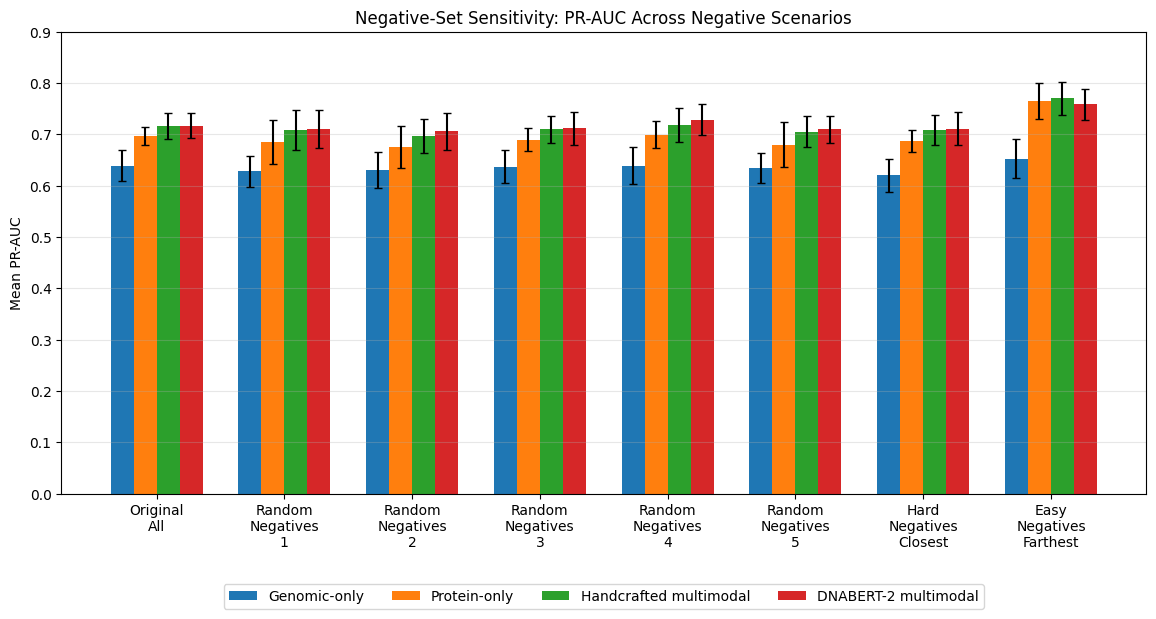

Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/figures/phase18_pr_auc_across_negative_scenarios.png


In [14]:
# ============================================================
# FIGURE 1 — PR-AUC ACROSS NEGATIVE SCENARIOS
# ============================================================

plot_metric = "pr_auc"

plot_df = phase18_summary_wide_df.copy()

scenario_order = [
    "Original_All",
    "Random_Negatives_1",
    "Random_Negatives_2",
    "Random_Negatives_3",
    "Random_Negatives_4",
    "Random_Negatives_5",
    "Hard_Negatives_Closest",
    "Easy_Negatives_Farthest"
]

scenario_order = [s for s in scenario_order if s in plot_df["scenario_name"].unique()]

model_order = [
    "Genomic-only",
    "Protein-only",
    "Handcrafted multimodal",
    "DNABERT-2 multimodal"
]

x = np.arange(len(scenario_order))
width = 0.18

plt.figure(figsize=(14, 6))

for i, model_display in enumerate(model_order):
    sub = plot_df[plot_df["display_name"] == model_display].copy()
    values = []
    errors = []

    for scenario in scenario_order:
        row = sub[sub["scenario_name"] == scenario]
        if row.empty:
            values.append(np.nan)
            errors.append(0)
        else:
            values.append(float(row[f"{plot_metric}_mean"].iloc[0]))
            errors.append(float(row[f"{plot_metric}_sd"].iloc[0]))

    plt.bar(
        x + (i - 1.5) * width,
        values,
        yerr=errors,
        width=width,
        capsize=3,
        label=model_display
    )

plt.xticks(x, [s.replace("_", "\n") for s in scenario_order], rotation=0)
plt.ylabel("Mean PR-AUC")
plt.title("Negative-Set Sensitivity: PR-AUC Across Negative Scenarios")
plt.ylim(0, 0.90)
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))

out_path = FIGURE_DIR / "phase18_pr_auc_across_negative_scenarios.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

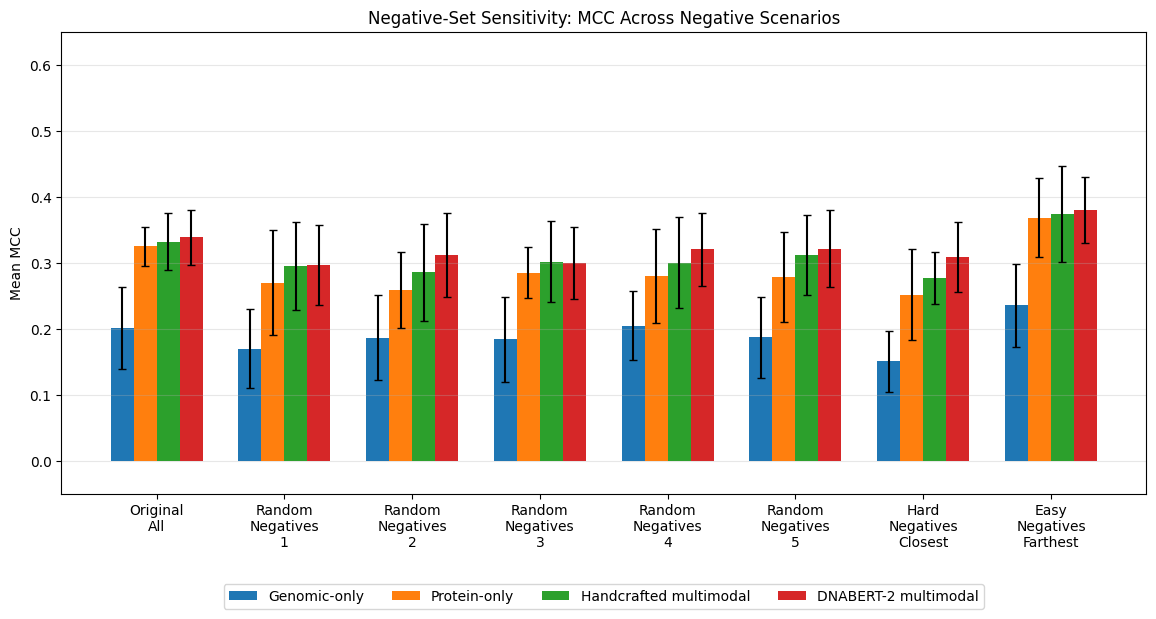

Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/figures/phase18_mcc_across_negative_scenarios.png


In [15]:
# ============================================================
# FIGURE 2 — MCC ACROSS NEGATIVE SCENARIOS
# ============================================================

plot_metric = "mcc"

plot_df = phase18_summary_wide_df.copy()

x = np.arange(len(scenario_order))
width = 0.18

plt.figure(figsize=(14, 6))

for i, model_display in enumerate(model_order):
    sub = plot_df[plot_df["display_name"] == model_display].copy()
    values = []
    errors = []

    for scenario in scenario_order:
        row = sub[sub["scenario_name"] == scenario]
        if row.empty:
            values.append(np.nan)
            errors.append(0)
        else:
            values.append(float(row[f"{plot_metric}_mean"].iloc[0]))
            errors.append(float(row[f"{plot_metric}_sd"].iloc[0]))

    plt.bar(
        x + (i - 1.5) * width,
        values,
        yerr=errors,
        width=width,
        capsize=3,
        label=model_display
    )

plt.xticks(x, [s.replace("_", "\n") for s in scenario_order], rotation=0)
plt.ylabel("Mean MCC")
plt.title("Negative-Set Sensitivity: MCC Across Negative Scenarios")
plt.ylim(-0.05, 0.65)
plt.grid(axis="y", alpha=0.3)
plt.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))

out_path = FIGURE_DIR / "phase18_mcc_across_negative_scenarios.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

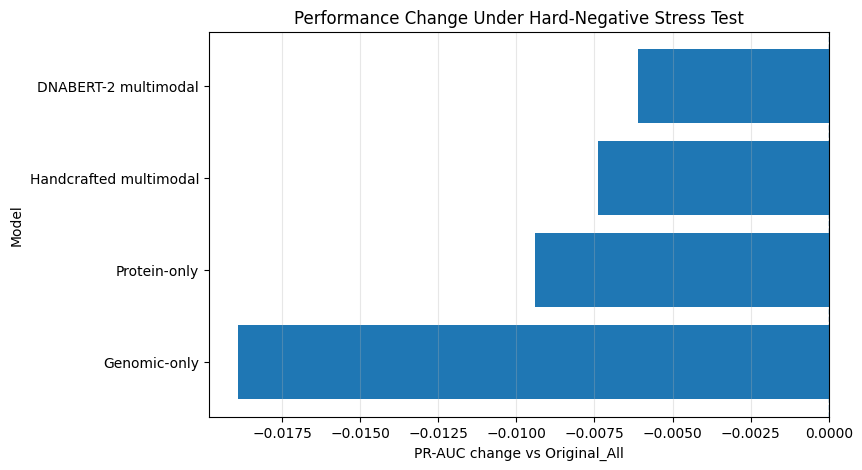

Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/figures/phase18_pr_auc_degradation_hard_negatives.png


In [16]:
# ============================================================
# FIGURE 3 — DEGRADATION UNDER HARD NEGATIVES
# ============================================================

hard_deg_df = degradation_df[
    degradation_df["scenario_name"] == "Hard_Negatives_Closest"
].copy()

if not hard_deg_df.empty:
    metric_to_plot = "pr_auc_delta_vs_original"

    hard_deg_df = hard_deg_df.sort_values(metric_to_plot, ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(hard_deg_df["display_name"], hard_deg_df[metric_to_plot])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("PR-AUC change vs Original_All")
    plt.ylabel("Model")
    plt.title("Performance Change Under Hard-Negative Stress Test")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / "phase18_pr_auc_degradation_hard_negatives.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
else:
    print("Hard negative degradation table is empty.")

In [17]:
# ============================================================
# MANUSCRIPT-READY INTERPRETATION
# ============================================================

# Extract key summaries
original_summary = phase18_summary_wide_df[
    phase18_summary_wide_df["scenario_name"] == "Original_All"
].copy()

hard_summary = phase18_summary_wide_df[
    phase18_summary_wide_df["scenario_name"] == "Hard_Negatives_Closest"
].copy()

easy_summary = phase18_summary_wide_df[
    phase18_summary_wide_df["scenario_name"] == "Easy_Negatives_Farthest"
].copy()

best_original_pr = original_summary.sort_values("pr_auc_mean", ascending=False).iloc[0]
best_original_mcc = original_summary.sort_values("mcc_mean", ascending=False).iloc[0]

methods_text = f"""
To evaluate the sensitivity of model performance to negative-gene selection, negative-set stress tests were performed. In addition to the original balanced dataset, alternative negative scenarios were constructed using random negative subsets, hard negatives and easy negatives. Hard negatives were defined as negative-labelled genes closest to the positive centroid in standardized ProtBERT embedding space, whereas easy negatives were defined as those farthest from the positive centroid. For each scenario, repeated stratified cross-validation was performed using the same model configurations as the main benchmark. Thresholds were selected within each fold by maximizing MCC on an inner validation split, and performance was evaluated on the held-out fold.
""".strip()

results_text = f"""
The negative-set sensitivity analysis assessed whether the model ranking was robust to alternative negative selections. In the original scenario, the strongest PR-AUC was achieved by {best_original_pr['display_name']} ({best_original_pr['pr_auc_mean']:.3f} ± {best_original_pr['pr_auc_sd']:.3f}), while the strongest MCC was achieved by {best_original_mcc['display_name']} ({best_original_mcc['mcc_mean']:.3f} ± {best_original_mcc['mcc_sd']:.3f}). Performance under hard-negative and easy-negative scenarios was compared with the original scenario to determine whether the models were relying on easily separable background genes. Consistent model ranking across random and hard-negative scenarios would support robustness to negative sampling, whereas large degradation under hard negatives would indicate that candidate prioritization remains sensitive to negative-set construction.
""".strip()

discussion_text = """
Negative-set sensitivity is essential for disease-gene prioritization because negative labels typically represent genes without known disease evidence rather than confirmed non-disease genes. Therefore, performance should not be interpreted as absolute diagnostic accuracy. Instead, robustness across alternative negative definitions provides evidence that the learned ranking is not solely driven by one arbitrary background set. If protein-containing and multimodal models remain superior to genomic-only models across random and hard-negative scenarios, this strengthens the conclusion that protein sequence representations provide the dominant signal. If DNABERT-2 and handcrafted multimodal models remain close across scenarios, the appropriate interpretation remains a ranking-versus-interpretability trade-off rather than a claim of clear DNABERT-2 superiority.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Negative-Set Sensitivity", "text": methods_text},
    {"section": "Results - Negative-Set Sensitivity", "text": results_text},
    {"section": "Discussion - Negative-Set Robustness", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase18_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase18_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved wording.")

,section,text
0,Methods - Negative-Set Sensitivity,"To evaluate the sensitivity of model performance to negative-gene selection, negative-set stress tests were performed. In addition to the original balanced dataset, alternative negative scenarios were constructed using random negative subsets, hard negatives and easy negatives. Hard negatives were defined as negative-labelled genes closest to the positive centroid in standardized ProtBERT embe..."
1,Results - Negative-Set Sensitivity,"The negative-set sensitivity analysis assessed whether the model ranking was robust to alternative negative selections. In the original scenario, the strongest PR-AUC was achieved by DNABERT-2 multimodal (0.717 ± 0.025), while the strongest MCC was achieved by DNABERT-2 multimodal (0.339 ± 0.042). Performance under hard-negative and easy-negative scenarios was compared with the original scenar..."
2,Discussion - Negative-Set Robustness,"Negative-set sensitivity is essential for disease-gene prioritization because negative labels typically represent genes without known disease evidence rather than confirmed non-disease genes. Therefore, performance should not be interpreted as absolute diagnostic accuracy. Instead, robustness across alternative negative definitions provides evidence that the learned ranking is not solely drive..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_manuscript_ready_wording.csv
Saved wording.


In [18]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase18_negative_set_sensitivity_tables.xlsx"

tables = {
    "Scenario_Summary": scenario_summary_df,
    "Scenario_Indices": scenario_index_df,
    "Metadata_Candidates": metadata_candidates_df,
    "Sample_Metadata": sample_metadata_df,
    "Negative_Hardness": neg_hardness_df,
    "All_Fold_Metrics": phase18_results_df,
    "All_Predictions": phase18_predictions_df,
    "Summary_Long": phase18_summary_long_df,
    "Summary_Wide": phase18_summary_wide_df,
    "Degradation_vs_Original": degradation_df,
    "Paired_By_Scenario": paired_sensitivity_df,
    "Rank_By_Scenario": rank_df,
    "Rank_Summary": rank_summary_df,
    "Wording": wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/excel/phase18_negative_set_sensitivity_tables.xlsx


In [19]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 18 COMPLETE ===")

print("\nScenario summary:")
display(scenario_summary_df)

print("\nSummary wide:")
display(phase18_summary_wide_df)

print("\nDegradation vs original:")
display(degradation_df)

print("\nPaired comparisons:")
display(paired_sensitivity_df[
    paired_sensitivity_df["comparison"].isin([
        "DNABERT2_multimodal minus Handcrafted_multimodal",
        "Handcrafted_multimodal minus Protein_only_ProtBERT_SW",
        "DNABERT2_multimodal minus Protein_only_ProtBERT_SW"
    ])
].head(80))

print("\nRank summary:")
display(rank_summary_df.head(80))

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 18 COMPLETE ===

Scenario summary:


,scenario_name,scenario_type,n_total,n_positive,n_negative,description
0,Original_All,original,1806,903,903,All original positives and all original negatives.
1,Random_Negatives_1,random_negative_subset,1400,700,700,Random subset of 700 negatives.
2,Random_Negatives_2,random_negative_subset,1400,700,700,Random subset of 700 negatives.
3,Random_Negatives_3,random_negative_subset,1400,700,700,Random subset of 700 negatives.
4,Random_Negatives_4,random_negative_subset,1400,700,700,Random subset of 700 negatives.
5,Random_Negatives_5,random_negative_subset,1400,700,700,Random subset of 700 negatives.
6,Hard_Negatives_Closest,hard_negatives,1400,700,700,Negatives closest to the positive centroid in standardized ProtBERT embedding space.
7,Easy_Negatives_Farthest,easy_negatives,1400,700,700,Negatives farthest from the positive centroid in standardized ProtBERT embedding space.



Summary wide:


,scenario_name,scenario_type,model_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,0.7587,0.0307,0.3797,0.0499,0.7655,0.0267,0.7048,0.0563
1,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,0.6531,0.0376,0.2356,0.0633,0.6485,0.0268,0.5488,0.0643
2,Easy_Negatives_Farthest,easy_negatives,Handcrafted_multimodal,Handcrafted multimodal,0.7706,0.0319,0.3744,0.0726,0.7719,0.0306,0.6927,0.0656
3,Easy_Negatives_Farthest,easy_negatives,Protein_only_ProtBERT_SW,Protein-only,0.7647,0.0352,0.3686,0.0599,0.7693,0.0296,0.6674,0.1181
4,Hard_Negatives_Closest,hard_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,0.7110,0.0322,0.3089,0.0532,0.7059,0.0247,0.5916,0.0695
5,Hard_Negatives_Closest,hard_negatives,Genomic_only_K3K4Basic,Genomic-only,0.6201,0.0324,0.1510,0.0462,0.6156,0.0230,0.4783,0.1277
6,Hard_Negatives_Closest,hard_negatives,Handcrafted_multimodal,Handcrafted multimodal,0.7088,0.0300,0.2772,0.0393,0.7023,0.0259,0.5628,0.0904
7,Hard_Negatives_Closest,hard_negatives,Protein_only_ProtBERT_SW,Protein-only,0.6871,0.0219,0.2519,0.0693,0.6848,0.0282,0.6046,0.0866
8,Original_All,original,DNABERT2_multimodal,DNABERT-2 multimodal,0.7171,0.0248,0.3385,0.0419,0.7325,0.0185,0.6532,0.0758
9,Original_All,original,Genomic_only_K3K4Basic,Genomic-only,0.6390,0.0303,0.2013,0.0622,0.6387,0.0350,0.5171,0.0872



Degradation vs original:


...


Paired comparisons:


,scenario_name,comparison,model_a,model_b,metric,mean_delta,sd_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,ties,wilcoxon_p,wilcoxon_bh_fdr_within_scenario
0,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,pr_auc,-0.01186,0.01230,-0.01791,-0.00574,2,13,0,0.00537,0.02148
1,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,mcc,0.00535,0.03705,-0.01251,0.02322,8,7,0,0.59949,0.77574
2,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,roc_auc,-0.00639,0.00814,-0.01041,-0.00247,3,12,0,0.01147,0.03060
3,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,f1,0.01216,0.04715,-0.00884,0.03739,9,6,0,0.63867,0.77574
4,Easy_Negatives_Farthest,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.00583,0.01397,-0.00090,0.01257,11,4,0,0.11824,0.27026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Random_Negatives_4,DNABERT2_multimodal minus Handcrafted_multimodal,DNABERT2_multimodal,Handcrafted_multimodal,f1,0.03610,0.10961,-0.01335,0.09286,8,7,0,0.52448,0.52448
100,Random_Negatives_4,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,pr_auc,0.01862,0.01715,0.00968,0.02644,13,2,0,0.00262,0.01050
101,Random_Negatives_4,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,mcc,0.02030,0.04983,-0.00295,0.04414,10,5,0,0.22931,0.24460
102,Random_Negatives_4,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,Handcrafted_multimodal,Protein_only_ProtBERT_SW,roc_auc,0.01124,0.01439,0.00387,0.01785,12,3,0,0.01508,0.02680



Rank summary:


,scenario_name,scenario_type,model_name,display_name,metric,mean_rank,sd_rank,n_rank1,n_evaluations
0,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,f1,1.8667,0.8338,6,15
1,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,mcc,2.0000,0.7559,4,15
2,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,pr_auc,2.5333,0.7432,2,15
3,Easy_Negatives_Farthest,easy_negatives,DNABERT2_multimodal,DNABERT-2 multimodal,roc_auc,2.4667,0.7432,2,15
4,Easy_Negatives_Farthest,easy_negatives,Genomic_only_K3K4Basic,Genomic-only,f1,3.9333,0.2582,0,15
...,...,...,...,...,...,...,...,...,...
75,Random_Negatives_2,random_negative_subset,Handcrafted_multimodal,Handcrafted multimodal,roc_auc,1.6000,0.5071,6,15
76,Random_Negatives_2,random_negative_subset,Protein_only_ProtBERT_SW,Protein-only,f1,2.3333,1.1127,5,15
77,Random_Negatives_2,random_negative_subset,Protein_only_ProtBERT_SW,Protein-only,mcc,2.8667,0.7432,0,15
78,Random_Negatives_2,random_negative_subset,Protein_only_ProtBERT_SW,Protein-only,pr_auc,3.0000,0.6547,0,15



Figures:
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/figures/phase18_mcc_across_negative_scenarios.png
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/figures/phase18_pr_auc_across_negative_scenarios.png
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/figures/phase18_pr_auc_degradation_hard_negatives.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_all_sample_hardness_scores.csv
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_manuscript_ready_wording.csv
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_metadata_candidates.csv
/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_negative_hardness_scores.csv
/content/drive/MyDrive/Project_Protei

In [20]:
display(scenario_summary_df)

display(phase18_summary_wide_df[[
    "scenario_name",
    "display_name",
    "pr_auc_mean",
    "pr_auc_sd",
    "mcc_mean",
    "mcc_sd",
    "roc_auc_mean",
    "roc_auc_sd",
    "f1_mean",
    "f1_sd"
]])

display(degradation_df[[
    "scenario_name",
    "display_name",
    "pr_auc_delta_vs_original",
    "mcc_delta_vs_original",
    "roc_auc_delta_vs_original",
    "f1_delta_vs_original"
]])

display(paired_sensitivity_df[[
    "scenario_name",
    "comparison",
    "metric",
    "mean_delta",
    "ci95_low",
    "ci95_high",
    "wins_model_a",
    "wins_model_b",
    "wilcoxon_p",
    "wilcoxon_bh_fdr_within_scenario"
]])

,scenario_name,scenario_type,n_total,n_positive,n_negative,description
0,Original_All,original,1806,903,903,All original positives and all original negatives.
1,Random_Negatives_1,random_negative_subset,1400,700,700,Random subset of 700 negatives.
2,Random_Negatives_2,random_negative_subset,1400,700,700,Random subset of 700 negatives.
3,Random_Negatives_3,random_negative_subset,1400,700,700,Random subset of 700 negatives.
4,Random_Negatives_4,random_negative_subset,1400,700,700,Random subset of 700 negatives.
5,Random_Negatives_5,random_negative_subset,1400,700,700,Random subset of 700 negatives.
6,Hard_Negatives_Closest,hard_negatives,1400,700,700,Negatives closest to the positive centroid in standardized ProtBERT embedding space.
7,Easy_Negatives_Farthest,easy_negatives,1400,700,700,Negatives farthest from the positive centroid in standardized ProtBERT embedding space.


,scenario_name,display_name,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,f1_mean,f1_sd
0,Easy_Negatives_Farthest,DNABERT-2 multimodal,0.7587,0.0307,0.3797,0.0499,0.7655,0.0267,0.7048,0.0563
1,Easy_Negatives_Farthest,Genomic-only,0.6531,0.0376,0.2356,0.0633,0.6485,0.0268,0.5488,0.0643
2,Easy_Negatives_Farthest,Handcrafted multimodal,0.7706,0.0319,0.3744,0.0726,0.7719,0.0306,0.6927,0.0656
3,Easy_Negatives_Farthest,Protein-only,0.7647,0.0352,0.3686,0.0599,0.7693,0.0296,0.6674,0.1181
4,Hard_Negatives_Closest,DNABERT-2 multimodal,0.7110,0.0322,0.3089,0.0532,0.7059,0.0247,0.5916,0.0695
5,Hard_Negatives_Closest,Genomic-only,0.6201,0.0324,0.1510,0.0462,0.6156,0.0230,0.4783,0.1277
6,Hard_Negatives_Closest,Handcrafted multimodal,0.7088,0.0300,0.2772,0.0393,0.7023,0.0259,0.5628,0.0904
7,Hard_Negatives_Closest,Protein-only,0.6871,0.0219,0.2519,0.0693,0.6848,0.0282,0.6046,0.0866
8,Original_All,DNABERT-2 multimodal,0.7171,0.0248,0.3385,0.0419,0.7325,0.0185,0.6532,0.0758
9,Original_All,Genomic-only,0.6390,0.0303,0.2013,0.0622,0.6387,0.0350,0.5171,0.0872


,scenario_name,display_name,pr_auc_delta_vs_original,mcc_delta_vs_original,roc_auc_delta_vs_original,f1_delta_vs_original
0,Easy_Negatives_Farthest,DNABERT-2 multimodal,0.0416,0.0412,0.0330,0.0516
1,Easy_Negatives_Farthest,Genomic-only,0.0141,0.0343,0.0098,0.0317
2,Easy_Negatives_Farthest,Handcrafted multimodal,0.0544,0.0425,0.0411,0.0421
3,Easy_Negatives_Farthest,Protein-only,0.0682,0.0437,0.0502,-0.0098
4,Hard_Negatives_Closest,DNABERT-2 multimodal,-0.0061,-0.0296,-0.0266,-0.0616
5,Hard_Negatives_Closest,Genomic-only,-0.0189,-0.0503,-0.0231,-0.0388
6,Hard_Negatives_Closest,Handcrafted multimodal,-0.0074,-0.0547,-0.0285,-0.0878
7,Hard_Negatives_Closest,Protein-only,-0.0094,-0.0730,-0.0343,-0.0726
8,Original_All,DNABERT-2 multimodal,0.0000,0.0000,0.0000,0.0000
9,Original_All,Genomic-only,0.0000,0.0000,0.0000,0.0000


,scenario_name,comparison,metric,mean_delta,ci95_low,ci95_high,wins_model_a,wins_model_b,wilcoxon_p,wilcoxon_bh_fdr_within_scenario
0,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,pr_auc,-0.01186,-0.01791,-0.00574,2,13,0.00537,0.02148
1,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,mcc,0.00535,-0.01251,0.02322,8,7,0.59949,0.77574
2,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,roc_auc,-0.00639,-0.01041,-0.00247,3,12,0.01147,0.03060
3,Easy_Negatives_Farthest,DNABERT2_multimodal minus Handcrafted_multimodal,f1,0.01216,-0.00884,0.03739,9,6,0.63867,0.77574
4,Easy_Negatives_Farthest,Handcrafted_multimodal minus Protein_only_ProtBERT_SW,pr_auc,0.00583,-0.00090,0.01257,11,4,0.11824,0.27026
...,...,...,...,...,...,...,...,...,...,...
123,Random_Negatives_5,DNABERT2_multimodal minus Protein_only_ProtBERT_SW,f1,-0.01051,-0.05633,0.03668,6,9,0.76154,0.76154
124,Random_Negatives_5,Protein_only_ProtBERT_SW minus Genomic_only_K3K4Basic,pr_auc,0.04637,0.02232,0.06975,11,4,0.00427,0.00760
125,Random_Negatives_5,Protein_only_ProtBERT_SW minus Genomic_only_K3K4Basic,mcc,0.09108,0.05546,0.12619,13,2,0.00043,0.00137
126,Random_Negatives_5,Protein_only_ProtBERT_SW minus Genomic_only_K3K4Basic,roc_auc,0.07313,0.05725,0.08829,15,0,0.00006,0.00098
